# Assignment 4 - Mini ASR with Kaldi (Myanmar)

End-to-end HMM-GMM (monophone -> triphone) plus one "advanced" model, scored
with **WER** and **SER** (Syllable Error Rate).

* **Corpus:** 6 speakers, 4 for training and 2 held out for testing (one male,
  one female voice - see `speaker_config.py`, which holds the actual recording
  folder names and is not checked into git), 5 passes x 150 prompts each
  (~4505 recordings in total). Audio source is **`../recordings_trim/`** =
  loudness-normalised (`tools/normalize_recordings.py`) then
  silence-trimmed (`tools/trim_silence.py`). Trimming is critical here: on
  raw audio an earlier run put **86% of training frames on silence** and
  never learned the speech.
* **Split** (matches the assignment spec: test = one male + one female
  speaker, all their recordings):
  * `train` / `dev` - the 4 training voices, all 5 passes, pooled and split
    ~88 / 12 at random (seed `SPLIT_SEED`). dev is **matched** to train, for
    comparing models.
  * `test` = the held-out male voice + the held-out female voice, all
    passes - **speaker-independent** (a couple of known-bad clips dropped,
    see `DROP_UTTS`).
* **Units:** the Myanmar **syllable itself is the phone** (~65 units, one
  3-state HMM each). The earlier grapheme decomposition made most "phones"
  bare tone/medial marks with no acoustic target. Segmentation:
  [`mm_syllable.py`](mm_syllable.py).
* **Features:** MFCC **+ 3 Kaldi pitch features** (Burmese is tonal - plain
  MFCCs drop the tone) + per-speaker CMVN. `--boost-silence 1.25` in
  training since the trimmed clips have very little silence left.
* **Language model:** closed-vocabulary **bigram** estimated from the training
  transcripts (the prompt set is fixed, so this is optimistic by design).
* **Kaldi:** runs inside Docker image `tklwin/kaldi-apple-silicon` (Apple
  Silicon native). Every Kaldi step in this notebook is a call to the
  `kaldi(...)` helper, which does `docker run` with the project mounted at
  `/workspace`.

> **Prereqs:** Docker Desktop running; `docker pull tklwin/kaldi-apple-silicon:latest`
> done once. This notebook's kernel is the repo venv
> (`../../.venv`, i.e. `AIEF_B2_References_Assignment/.venv`).

## 1 - Configuration

In [4]:
import os, re, shutil, subprocess, sys, json, unicodedata
from pathlib import Path
import pandas as pd

# --- paths (host) ---
NB_DIR   = Path.cwd()                     # .../B2-Assignment4/step3_asr
PROJ     = NB_DIR.parent                  # .../B2-Assignment4          <- mounted as /workspace
S5       = NB_DIR / "s5"                  # Kaldi working dir (this experiment)
# Audio source. "recordings_trim" = loudness-normalised + silence-trimmed
# (tools/normalize_recordings.py then tools/trim_silence.py). The grapheme-phone
# run on raw audio put 86% of frames on silence and never learned the speech;
# trimming + syllable units + pitch features are this run's fix.
REC_SET  = "recordings_trim"
RECS     = PROJ / REC_SET
S5.mkdir(exist_ok=True)

# --- container ---
IMAGE       = "tklwin/kaldi-apple-silicon:latest"
WS          = "/workspace"                # PROJ inside the container
S5_WS       = "/workspace/step3_asr/s5"   # S5 inside the container
KALDI_ROOT  = "/opt/kaldi"

# --- run params ---
# Kaldi splits data BY SPEAKER, so nj must be <= #speakers actually present in
# that set. train pool has 4 speakers (reliably all present in the 88% split);
# dev is a small random 12% slice - keep its nj conservative in case a
# speaker is thin in that draw. test always has exactly 2 (1 male + 1 female).
NJ_TRAIN  = 4
NJ_DECODE = {"train": 4, "dev": 2, "test": 2}
MFCC_CONF = "--use-energy=false --sample-frequency=16000"
LM_ORDER  = 2

# --- split (matches the assignment spec) ---
# dev is a MATCHED random hold-out from the train speakers (same speakers /
# passes / channel as train) so it is useful for comparing models.
# test = one male + one female speaker, all their utterances -> speaker-
# independent, the number the assignment actually asks for.
#
# Which recording folders are used for what lives in speaker_config.py, which
# is NOT tracked by git (folder names may be real people's names) - copy
# speaker_config.example.py to speaker_config.py and fill in your own.
sys.path.insert(0, str(NB_DIR))
try:
    from speaker_config import TRAIN_SPEAKER_DIRS, TEST_SPEAKER_DIRS, DROP_UTTS
except ImportError as e:
    raise SystemExit(
        "Missing step3_asr/speaker_config.py - copy speaker_config.example.py "
        "to speaker_config.py and fill in your recording folder names."
    ) from e

ALL_PASSES     = [1, 2, 3, 4, 5]
TRAIN_SPEAKERS = [(d, ALL_PASSES) for d in TRAIN_SPEAKER_DIRS]
TEST_SPEAKERS  = [(TEST_SPEAKER_DIRS["male"], ALL_PASSES), (TEST_SPEAKER_DIRS["female"], ALL_PASSES)]
DEV_FRACTION   = 0.12
SPLIT_SEED     = 1234

# GMM tree/gauss sizes - scaled for training-set size (the Kaldi wsj defaults
# 2000/11000, 2500/15000 badly overfit a small corpus). Was 700/6000, 1000/8000
# for ~1300 utts / 2 speakers; roughly doubled now that train is ~2600 utts /
# 4 speakers. Adjust again as more speakers land.
GMM_SIZES = {"tri1": (1200, 9000), "tri2": (1800, 12000), "tri3": (1800, 12000)}

# Standard Kaldi wsj/librispeech value; helps the (now small, post-trim) sil
# model train without dominating. The silence-collapse in earlier runs was
# actually the syllable-lexicon OOV bug, not a boost-silence issue.
BOOST_SIL = 1.25

print("PROJ :", PROJ)
print("S5   :", S5)
assert RECS.is_dir(), RECS

PROJ : /Users/acnmacm4/ACNM4_Workstation/AIEF_ACN/AIEF_B2_References_Assignment/B2-Assignment4
S5   : /Users/acnmacm4/ACNM4_Workstation/AIEF_ACN/AIEF_B2_References_Assignment/B2-Assignment4/step3_asr/s5


## 2 - The `kaldi()` helper

Runs a bash snippet inside the image with `PROJ` mounted at `/workspace` and the
working directory set to `s5/`. `path.sh` (written in the next cell) puts the
Kaldi binaries and `steps/`, `utils/` on `PATH`.

In [5]:
def _docker_base(interactive=False):
    return [
        "docker", "run", "--rm",
        *(["-it"] if interactive else []),
        "-v", f"{PROJ}:{WS}",
        "-w", S5_WS,
        "-e", "LC_ALL=C",
        IMAGE,
    ]

def kaldi(script: str, check=True, quiet=False):
    # Run `script` in bash inside the container (after sourcing ./path.sh).
    full = f"set -euo pipefail; source ./path.sh 2>/dev/null || true; {script}"
    cmd = _docker_base() + ["bash", "-lc", full]
    if not quiet:
        print("$", script if len(script) < 200 else script[:200] + " ...")
    p = subprocess.run(cmd, capture_output=True, text=True)
    if p.stdout and not quiet:
        print(p.stdout.rstrip())
    if p.returncode != 0:
        print(p.stderr.rstrip(), file=sys.stderr)
        if check:
            raise RuntimeError(f"kaldi step failed ({p.returncode}): {script[:120]}")
    return p

def kaldi_out(script: str) -> str:
    return kaldi(script, quiet=True).stdout

# smoke test - image present & Kaldi callable
_p = subprocess.run(_docker_base() + ["bash","-lc",
        "echo KALDI_ROOT=$KALDI_ROOT; ls $KALDI_ROOT/egs/wsj/s5 | tr '\\n' ' '; "
        "which compute-mfcc-feats gmm-init-mono arpa2fst nnet3-init 2>&1"],
     capture_output=True, text=True)
print(_p.stdout or _p.stderr)

KALDI_ROOT=/opt/kaldi
RESULTS cmd.sh conf local path.sh rnnlm run.sh steps utils 


## 3 - Working directory: `path.sh`, `cmd.sh`, `steps/`, `utils/`, `conf/`

In [6]:
# path.sh - sourced by kaldi() and by Kaldi's own scripts
(S5 / "path.sh").write_text(
    'export KALDI_ROOT=/opt/kaldi\n'
    '[ -f $KALDI_ROOT/tools/env.sh ] && . $KALDI_ROOT/tools/env.sh\n'
    'export PATH=$PWD/utils:$KALDI_ROOT/tools/openfst/bin:$PWD:$PATH\n'
    'if [ -f $KALDI_ROOT/tools/config/common_path.sh ]; then\n'
    '  . $KALDI_ROOT/tools/config/common_path.sh\n'
    'else\n'
    '  for d in $KALDI_ROOT/src/*bin; do export PATH=$d:$PATH; done\n'
    'fi\n'
    'export LC_ALL=C\n', encoding="utf-8")

# cmd.sh - all local, no scheduler
(S5 / "cmd.sh").write_text(
    'export train_cmd="run.pl"\n'
    'export decode_cmd="run.pl"\n'
    'export cuda_cmd="run.pl"\n', encoding="utf-8")

# steps/ and utils/ come from the wsj recipe inside the image; local/ we make
# ourselves. mm_syllable.py is copied in so container-side python can import it.
shutil.copy2(NB_DIR / "mm_syllable.py", S5 / "mm_syllable.py")
(S5 / "syl_tok.py").write_text(
    "import sys\n"
    "from mm_syllable import syllable_break\n"
    "for line in sys.stdin:\n"
    "    p = line.rstrip('\\n').split(None, 1)\n"
    "    print(p[0], *(syllable_break(p[1]) if len(p) > 1 else []))\n",
    encoding="utf-8")
(S5 / "local").mkdir(exist_ok=True)

kaldi(
  'ln -sfn $KALDI_ROOT/egs/wsj/s5/steps steps; '
  'ln -sfn $KALDI_ROOT/egs/wsj/s5/utils utils; '
  'mkdir -p conf exp data; '
  'printf -- "%s\\n" "--use-energy=false" "--sample-frequency=16000" > conf/mfcc.conf; '
  'ls -l steps utils && echo "--- scoring script ---" && ls steps/scoring/score_kaldi_wer.sh')

$ ln -sfn $KALDI_ROOT/egs/wsj/s5/steps steps; ln -sfn $KALDI_ROOT/egs/wsj/s5/utils utils; mkdir -p conf exp data; printf -- "%s\n" "--use-energy=false" "--sample-frequency=16000" > conf/mfcc.conf; ls -l ...
lrwxr-xr-x 1 root root 27 Sep 12 03:36 steps -> /opt/kaldi/egs/wsj/s5/steps
lrwxr-xr-x 1 root root 27 Sep 12 03:36 utils -> /opt/kaldi/egs/wsj/s5/utils
--- scoring script ---
steps/scoring/score_kaldi_wer.sh


CompletedProcess(args=['docker', 'run', '--rm', '-v', '/Users/acnmacm4/ACNM4_Workstation/AIEF_ACN/AIEF_B2_References_Assignment/B2-Assignment4:/workspace', '-w', '/workspace/step3_asr/s5', '-e', 'LC_ALL=C', 'tklwin/kaldi-apple-silicon:latest', 'bash', '-lc', 'set -euo pipefail; source ./path.sh 2>/dev/null || true; ln -sfn $KALDI_ROOT/egs/wsj/s5/steps steps; ln -sfn $KALDI_ROOT/egs/wsj/s5/utils utils; mkdir -p conf exp data; printf -- "%s\\n" "--use-energy=false" "--sample-frequency=16000" > conf/mfcc.conf; ls -l steps utils && echo "--- scoring script ---" && ls steps/scoring/score_kaldi_wer.sh'], returncode=0, stdout='lrwxr-xr-x 1 root root 27 Sep 12 03:36 steps -> /opt/kaldi/egs/wsj/s5/steps\nlrwxr-xr-x 1 root root 27 Sep 12 03:36 utils -> /opt/kaldi/egs/wsj/s5/utils\n--- scoring script ---\nsteps/scoring/score_kaldi_wer.sh\n', stderr='')

## 4 - Data preparation

Build Kaldi `data/{train,dev,test}` from the recordings. `wav.scp` uses
container paths (`/workspace/recordings/...`); transcripts are normalised (NFC,
drop ASCII punctuation / commas, collapse spaces).

* **train / dev** - all 5 passes of the two train speakers, pooled and split
  `DEV_FRACTION` at random (seed `SPLIT_SEED`). dev is therefore *matched* to
  train (same speakers, passes, mic) - the right set for **comparing models**.
* **test** - the third speaker, held out entirely -> **speaker-independent**,
  the hard number and the one the assignment cares about.

In [7]:
import random
sys.path.insert(0, str(NB_DIR))
from mm_syllable import syllable_break

PUNCT = re.compile(r"[,\.‘’\"'()\[\]/:;!?]+")

def norm_text(s: str) -> str:
    # NFC, drop punctuation, then SYLLABLE-SEGMENT so the transcript tokens match
    # the syllable lexicon. Without this ~74% of `text` tokens (multi-syllable
    # words like "နံပါတ်", multi-digit numbers like "၁၅") were OOV -> mapped to
    # <UNK>/spn, and the acoustic models aligned ~90% of frames to silence/spn.
    s = unicodedata.normalize("NFC", s.strip())
    s = PUNCT.sub(" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return " ".join(syllable_break(s))

def collect(spec):
    # -> list of (utt, spk, container_wav_path, normalised_text) for a speaker/pass spec
    rows = []
    for spk, passes in spec:
        for pz in passes:
            pdir = RECS / spk / f"Rec{pz}"
            t = {}
            for ln in (pdir / "text").read_text(encoding="utf-8").splitlines():
                if ln.strip():
                    k, _, v = ln.partition(" "); t[k] = v
            for utt in sorted(t):
                if utt in DROP_UTTS:
                    continue
                raw = unicodedata.normalize("NFC", t[utt].strip())
                raw = re.sub(r"\s+", " ", PUNCT.sub(" ", raw)).strip()
                rows.append((utt, spk, f"{WS}/{REC_SET}/{spk}/Rec{pz}/{utt}.wav",
                             norm_text(t[utt]),   # syllable-segmented (for Kaldi + SER)
                             raw))                # original whitespace tokens (for WER)
    return rows

def write_data_dir(name, rows):
    d = S5 / "data" / name
    d.mkdir(parents=True, exist_ok=True)
    cols = {"wav.scp": lambda r: f"{r[0]} {r[2]}",
            "text":    lambda r: f"{r[0]} {r[3]}",
            "utt2spk": lambda r: f"{r[0]} {r[1]}"}
    for fn, f in cols.items():
        (d / fn).write_text("\n".join(sorted(f(r) for r in rows)) + "\n", encoding="utf-8")
    # word-level reference for WER, kept OUTSIDE the data dir (fix_data_dir won't touch it)
    (S5 / "data/local").mkdir(parents=True, exist_ok=True)
    (S5 / "data/local" / f"{name}.wordref").write_text(
        "\n".join(sorted(f"{r[0]} {r[4]}" for r in rows)) + "\n", encoding="utf-8")
    return d

pool = collect(TRAIN_SPEAKERS)
random.Random(SPLIT_SEED).shuffle(pool)
n_dev = int(round(len(pool) * DEV_FRACTION))
dev_rows, train_rows = pool[:n_dev], pool[n_dev:]
test_rows = collect(TEST_SPEAKERS)

for nm, rows in [("train", train_rows), ("dev", dev_rows), ("test", test_rows)]:
    write_data_dir(nm, rows)
    kaldi(f"utils/utt2spk_to_spk2utt.pl data/{nm}/utt2spk > data/{nm}/spk2utt; "
          f"utils/fix_data_dir.sh data/{nm}; "
          f"wc -l < data/{nm}/text | xargs echo 'data/{nm} utterances:'")
print(f"train {len(train_rows)} | dev {len(dev_rows)} (random {DEV_FRACTION:.0%} of "
      f"{len(pool)}, seed {SPLIT_SEED}) | test {len(test_rows)} (unseen speaker)")

$ utils/utt2spk_to_spk2utt.pl data/train/utt2spk > data/train/spk2utt; utils/fix_data_dir.sh data/train; wc -l < data/train/text | xargs echo 'data/train utterances:'
fix_data_dir.sh: kept all 2645 utterances.
fix_data_dir.sh: old files are kept in data/train/.backup
data/train utterances: 2645
$ utils/utt2spk_to_spk2utt.pl data/dev/utt2spk > data/dev/spk2utt; utils/fix_data_dir.sh data/dev; wc -l < data/dev/text | xargs echo 'data/dev utterances:'
fix_data_dir.sh: kept all 361 utterances.
fix_data_dir.sh: old files are kept in data/dev/.backup
data/dev utterances: 361
$ utils/utt2spk_to_spk2utt.pl data/test/utt2spk > data/test/spk2utt; utils/fix_data_dir.sh data/test; wc -l < data/test/text | xargs echo 'data/test utterances:'
fix_data_dir.sh: kept all 1497 utterances.
fix_data_dir.sh: old files are kept in data/test/.backup
data/test utterances: 1497
train 2645 | dev 361 (random 12% of 3006, seed 1234) | test 1497 (unseen speaker)


In [8]:
# quick look at the units in the training text
train_text = [l.split(" ",1)[1] for l in (S5/"data/train/text").read_text(encoding="utf-8").splitlines()]
syls = sorted({s for line in train_text for s in syllable_break(line)})
print(f"train: {len(train_text)} utts | {len(syls)} unique syllables (each = one phone/unit)")
print(" ".join(syls))

train: 2645 utts | 64 unique syllables (each = one phone/unit)
က ကို က် ကျ ကြိ ခု ချ ဂု င် ငွေ စ စ် စွဲ ဇ ဇူ ဇွ ည်း တ တို တ် တွ ထ ဒါ န နံ န် န်း နှိ ပါ ပ် ပြီ ပြော ဖု ဖေ ဖော် ဖြ ဘာ မ မေ မ် မှု ယ် ရ ရီ ရေ ရွေး လ လို ဝါ အ အော အော် ဧ ဩ ၀ ၁ ၂ ၃ ၄ ၅ ၆ ၇ ၈ ၉


## 5 - Lexicon & `lang/`

**Unit = the whole syllable** (this run's change). The earlier grapheme
decomposition made ~15 of ~47 "phones" bare tone/medial marks with no
acoustic target - the models never learned. Here each of the ~65 training
syllables gets one 3-state HMM. The *word* in `words.txt` / `text` / the LM
stays the Unicode syllable; the *phone* is an ASCII id (`S001`, `S002`, ...)
- Kaldi's `prepare_lang.sh` mangles multi-code-point phone names, ASCII ones
are safe. `data/local/syl2phone.txt` records the map for reference.

Then `utils/prepare_lang.sh` builds `data/lang/` (L.fst etc.).

In [9]:
dd = S5 / "data/local/dict"; dd.mkdir(parents=True, exist_ok=True)

syl2ph = {s: f"S{i:03d}" for i, s in enumerate(syls, 1)}   # syllable -> ASCII phone id
(dd.parent / "syl2phone.txt").write_text(
    "\n".join(f"{s}\t{p}" for s, p in syl2ph.items()) + "\n", encoding="utf-8")

lex = ["!SIL sil", "<UNK> spn"] + [f"{s} {syl2ph[s]}" for s in syls]
phones = list(syl2ph.values())
(dd / "lexicon.txt").write_text("\n".join(lex) + "\n", encoding="utf-8")
(dd / "nonsilence_phones.txt").write_text("\n".join(phones) + "\n", encoding="utf-8")
(dd / "silence_phones.txt").write_text("sil\nspn\n", encoding="utf-8")
(dd / "optional_silence.txt").write_text("sil\n", encoding="utf-8")
(dd / "extra_questions.txt").write_text("", encoding="utf-8")

kaldi('utils/prepare_lang.sh data/local/dict "<UNK>" data/local/lang data/lang '
      '&& echo "--- phones ---" && head -n 5 data/lang/phones.txt && echo ... '
      '&& echo "words:" $(wc -l < data/lang/words.txt)')

$ utils/prepare_lang.sh data/local/dict "<UNK>" data/local/lang data/lang && echo "--- phones ---" && head -n 5 data/lang/phones.txt && echo ... && echo "words:" $(wc -l < data/lang/words.txt)
utils/prepare_lang.sh data/local/dict <UNK> data/local/lang data/lang
Checking data/local/dict/silence_phones.txt ...
--> reading data/local/dict/silence_phones.txt
--> text seems to be UTF-8 or ASCII, checking whitespaces
--> text contains only allowed whitespaces
--> data/local/dict/silence_phones.txt is OK

Checking data/local/dict/optional_silence.txt ...
--> reading data/local/dict/optional_silence.txt
--> text seems to be UTF-8 or ASCII, checking whitespaces
--> text contains only allowed whitespaces
--> data/local/dict/optional_silence.txt is OK

Checking data/local/dict/nonsilence_phones.txt ...
--> reading data/local/dict/nonsilence_phones.txt
--> text seems to be UTF-8 or ASCII, checking whitespaces
--> text contains only allowed whitespaces
--> data/local/dict/nonsilence_phones.txt is 

CompletedProcess(args=['docker', 'run', '--rm', '-v', '/Users/acnmacm4/ACNM4_Workstation/AIEF_ACN/AIEF_B2_References_Assignment/B2-Assignment4:/workspace', '-w', '/workspace/step3_asr/s5', '-e', 'LC_ALL=C', 'tklwin/kaldi-apple-silicon:latest', 'bash', '-lc', 'set -euo pipefail; source ./path.sh 2>/dev/null || true; utils/prepare_lang.sh data/local/dict "<UNK>" data/local/lang data/lang && echo "--- phones ---" && head -n 5 data/lang/phones.txt && echo ... && echo "words:" $(wc -l < data/lang/words.txt)'], returncode=0, stdout='utils/prepare_lang.sh data/local/dict <UNK> data/local/lang data/lang\nChecking data/local/dict/silence_phones.txt ...\n--> reading data/local/dict/silence_phones.txt\n--> text seems to be UTF-8 or ASCII, checking whitespaces\n--> text contains only allowed whitespaces\n--> data/local/dict/silence_phones.txt is OK\n\nChecking data/local/dict/optional_silence.txt ...\n--> reading data/local/dict/optional_silence.txt\n--> text seems to be UTF-8 or ASCII, checking w

## 6 - Language model  (bigram -> `G.fst`)

Estimate a simple **bigram** (add-one smoothed) over syllable tokens from the
training transcripts, write it as ARPA, and compile to `data/lang_test/G.fst`
with `arpa2fst`.

In [10]:
from collections import Counter
import math

BOS, EOS = "<s>", "</s>"
uni, bi = Counter(), Counter()
for line in train_text:
    toks = [BOS] + syllable_break(line) + [EOS]
    uni.update(toks)
    bi.update(zip(toks[:-1], toks[1:]))

V = sorted(set(uni) - {BOS, EOS}) + [EOS]          # predictable tokens
vocab = set(V) | {BOS}
def logp(w, h):                                     # add-one bigram, log10
    return math.log10((bi[(h, w)] + 1) / (uni[h] + len(vocab)))

arpa = S5 / "data/local/lm.arpa"
lines = ["", "\\data\\", f"ngram 1={len(V)+1}", f"ngram 2={sum(1 for _ in bi)}", "", "\\1-grams:"]
for w in [BOS] + V:
    p = math.log10(max(uni[w], 1) / sum(uni.values()))
    lines.append(f"{p:.5f}\t{w}" + ("" if w == EOS else "\t-1.0"))
lines += ["", "\\2-grams:"]
for (h, w), c in bi.items():
    lines.append(f"{logp(w, h):.5f}\t{h} {w}")
lines += ["", "\\end\\", ""]
arpa.write_text("\n".join(lines), encoding="utf-8")
print(arpa.read_text(encoding='utf-8')[:400], "...")

kaldi(
  'mkdir -p data/lang_test && cp -r data/lang/* data/lang_test/ && '
  'arpa2fst --disambig-symbol="#0" --read-symbol-table=data/lang_test/words.txt '
  '  data/local/lm.arpa data/lang_test/G.fst && '
  'fstisstochastic data/lang_test/G.fst || true && '
  'utils/validate_lang.pl --skip-determinization-check data/lang_test && echo LANG_TEST_OK')


\data\
ngram 1=66
ngram 2=232

\1-grams:
-0.94045	<s>	-1.0
-1.81265	က	-1.0
-2.02842	ကို	-1.0
-1.60170	က်	-1.0
-2.12483	ကျ	-1.0
-3.08412	ကြိ	-1.0
-2.11003	ခု	-1.0
-2.40864	ချ	-1.0
-3.06185	ဂု	-1.0
-2.83140	င်	-1.0
-2.12483	ငွေ	-1.0
-3.15876	စ	-1.0
-3.08412	စ်	-1.0
-2.10281	စွဲ	-1.0
-3.08412	ဇ	-1.0
-3.10761	ဇူ	-1.0
-3.08412	ဇွ	-1.0
-2.78309	ည်း	-1.0
-2.81881	တ	-1.0
-3.10761	တို	-1.0
-1.44067	တ်	-1. ...
$ mkdir -p data/lang_test && cp -r data/lang/* data/lang_test/ && arpa2fst --disambig-symbol="#0" --read-symbol-table=data/lang_test/words.txt   data/local/lm.arpa data/lang_test/G.fst && fstisstochasti ...
1.17987 -0.0787423
utils/validate_lang.pl data/lang_test
Checking existence of separator file
separator file data/lang_test/subword_separator.txt is empty or does not exist, deal in word case.
Checking data/lang_test/phones.txt ...
--> text seems to be UTF-8 or ASCII, checking whitespaces
--> text contains only allowed whitespaces
--> data/lang_test/phones.txt is OK

Checking words.txt

CompletedProcess(args=['docker', 'run', '--rm', '-v', '/Users/acnmacm4/ACNM4_Workstation/AIEF_ACN/AIEF_B2_References_Assignment/B2-Assignment4:/workspace', '-w', '/workspace/step3_asr/s5', '-e', 'LC_ALL=C', 'tklwin/kaldi-apple-silicon:latest', 'bash', '-lc', 'set -euo pipefail; source ./path.sh 2>/dev/null || true; mkdir -p data/lang_test && cp -r data/lang/* data/lang_test/ && arpa2fst --disambig-symbol="#0" --read-symbol-table=data/lang_test/words.txt   data/local/lm.arpa data/lang_test/G.fst && fstisstochastic data/lang_test/G.fst || true && utils/validate_lang.pl --skip-determinization-check data/lang_test && echo LANG_TEST_OK'], returncode=0, stdout='1.17987 -0.0787423\nutils/validate_lang.pl data/lang_test\nChecking existence of separator file\nseparator file data/lang_test/subword_separator.txt is empty or does not exist, deal in word case.\nChecking data/lang_test/phones.txt ...\n--> text seems to be UTF-8 or ASCII, checking whitespaces\n--> text contains only allowed whitespac

## 7 - Features: MFCC **+ pitch** + CMVN

Burmese is tonal - many syllables differ only in tone, which plain MFCCs
throw away. `steps/make_mfcc_pitch.sh` appends Kaldi's 3 pitch features
(POV, normalised log-pitch, delta-pitch) -> 16-dim before deltas.

In [11]:
# empty conf files -> Kaldi defaults (16 kHz already set via --sample-frequency below)
kaldi('printf -- "%s\\n" "--sample-frequency=16000" "--use-energy=false" > conf/mfcc.conf; '
      'printf -- "%s\\n" "--sample-frequency=16000" > conf/pitch.conf; cat conf/mfcc.conf conf/pitch.conf')

for nm in ("train", "dev", "test"):
    kaldi(f"steps/make_mfcc_pitch.sh --nj {NJ_TRAIN} --mfcc-config conf/mfcc.conf "
          f"  --pitch-config conf/pitch.conf --cmd run.pl data/{nm} exp/make_mfcc/{nm} mfcc")
    kaldi(f"steps/compute_cmvn_stats.sh data/{nm} exp/make_mfcc/{nm} mfcc")
    kaldi(f"utils/fix_data_dir.sh data/{nm}")
kaldi("for n in train dev test; do echo -n \"$n feat-dim: \"; feat-to-dim "
      "scp:data/$n/feats.scp -; done")

$ printf -- "%s\n" "--sample-frequency=16000" "--use-energy=false" > conf/mfcc.conf; printf -- "%s\n" "--sample-frequency=16000" > conf/pitch.conf; cat conf/mfcc.conf conf/pitch.conf
--sample-frequency=16000
--use-energy=false
--sample-frequency=16000
$ steps/make_mfcc_pitch.sh --nj 4 --mfcc-config conf/mfcc.conf   --pitch-config conf/pitch.conf --cmd run.pl data/train exp/make_mfcc/train mfcc
steps/make_mfcc_pitch.sh --nj 4 --mfcc-config conf/mfcc.conf --pitch-config conf/pitch.conf --cmd run.pl data/train exp/make_mfcc/train mfcc
steps/make_mfcc_pitch.sh: moving data/train/feats.scp to data/train/.backup
utils/validate_data_dir.sh: Successfully validated data-directory data/train
steps/make_mfcc_pitch.sh: [info]: no segments file exists: assuming wav.scp indexed by utterance.
steps/make_mfcc_pitch.sh: Succeeded creating MFCC and pitch features for train
$ steps/compute_cmvn_stats.sh data/train exp/make_mfcc/train mfcc
steps/compute_cmvn_stats.sh data/train exp/make_mfcc/train mfcc
Su

CompletedProcess(args=['docker', 'run', '--rm', '-v', '/Users/acnmacm4/ACNM4_Workstation/AIEF_ACN/AIEF_B2_References_Assignment/B2-Assignment4:/workspace', '-w', '/workspace/step3_asr/s5', '-e', 'LC_ALL=C', 'tklwin/kaldi-apple-silicon:latest', 'bash', '-lc', 'set -euo pipefail; source ./path.sh 2>/dev/null || true; for n in train dev test; do echo -n "$n feat-dim: "; feat-to-dim scp:data/$n/feats.scp -; done'], returncode=0, stdout='train feat-dim: 16\ndev feat-dim: 16\ntest feat-dim: 16\n', stderr='feat-to-dim scp:data/train/feats.scp - \nfeat-to-dim scp:data/dev/feats.scp - \nfeat-to-dim scp:data/test/feats.scp - \n')

## 8 - Decode + score helper (SER + WER)

`text` is syllable-segmented, so Kaldi's own scorer gives the **SER** (syllable
error rate) directly. For **WER** the syllable hypothesis is greedily
re-segmented into the prompt's whitespace "words" (closed 150-prompt
vocabulary, longest-match) and scored against `data/local/<set>.wordref`.
Results accumulate in `RESULTS`.

In [12]:
RESULTS = []

# closed word vocabulary = every whitespace token across the prompt set
WORD_VOCAB = sorted(
    {w for f in ("train", "dev", "test")
       for l in (S5 / "data/local" / f"{f}.wordref").read_text(encoding="utf-8").splitlines()
       for w in l.split()[1:]},
    key=len, reverse=True)                      # longest first for greedy matching

def _resegment(syls: list[str]) -> list[str]:
    s = "".join(syls)
    out, i = [], 0
    while i < len(s):
        for w in WORD_VOCAB:
            if s.startswith(w, i):
                out.append(w); i += len(w); break
        else:
            out.append(s[i]); i += 1           # fallback: single char
    return out

def _best_params(decode_dir: str):
    txt = kaldi_out(f"cat {decode_dir}/scoring_kaldi/best_wer").strip()
    ser = float(re.search(r"%WER (\S+)", txt).group(1))     # 'text' is syllables -> this is SER
    lmwt, pen = re.search(r"wer_(\d+)_([0-9.]+)", txt).groups()
    return ser, lmwt, pen

def _word_wer(dec: str, data: str, lmwt: str, pen: str) -> float:
    hyp_lines = kaldi_out(f"cat {dec}/scoring_kaldi/penalty_{pen}/{lmwt}.txt").splitlines()
    ref = {l.split()[0]: l.split()[1:] for l in
           (S5 / "data/local" / f"{data}.wordref").read_text(encoding="utf-8").splitlines() if l.strip()}
    rp, hp = S5 / f"{dec}/wer_ref.txt", S5 / f"{dec}/wer_hyp.txt"
    (S5 / dec).mkdir(parents=True, exist_ok=True)
    with rp.open("w", encoding="utf-8") as rf, hp.open("w", encoding="utf-8") as hf:
        for l in hyp_lines:
            p = l.split()
            u = p[0]
            if u not in ref:
                continue
            rf.write(f"{u} {' '.join(ref[u])}\n")
            hf.write(f"{u} {' '.join(_resegment(p[1:]))}\n")
    out = kaldi_out(f"compute-wer --text --mode=present "
                    f"ark:{dec}/wer_ref.txt ark:{dec}/wer_hyp.txt 2>/dev/null | head -1")
    m = re.search(r"%WER (\S+)", out)
    return float(m.group(1)) if m else float("nan")

def decode_and_score(exp_dir, graph="graph", fmllr=False, decoder=None):
    name = exp_dir.split("/")[-1]
    for data in ("dev", "test"):
        dec = f"{exp_dir}/decode_{data}"
        nj = NJ_DECODE[data]
        if decoder:
            decoder(data, nj)
        elif fmllr:
            kaldi(f"steps/decode_fmllr.sh --nj {nj} --cmd run.pl --skip-scoring true "
                  f"  {exp_dir}/{graph} data/{data} {dec}")
        else:
            kaldi(f"steps/decode.sh --nj {nj} --cmd run.pl --skip-scoring true "
                  f"  {exp_dir}/{graph} data/{data} {dec}")
        kaldi(f"steps/scoring/score_kaldi_wer.sh --cmd run.pl data/{data} {exp_dir}/{graph} {dec}")
        ser, lmwt, pen = _best_params(dec)
        wer = _word_wer(dec, data, lmwt, pen)
        RESULTS.append({"model": name, "data": data, "WER": wer, "SER": ser,
                        "lmwt": int(lmwt), "pen": pen})
        print(f"  {name}/{data}:  WER={wer:.2f}  SER={ser:.2f}  (lmwt={lmwt}, pen={pen})")
    return pd.DataFrame([r for r in RESULTS if r["model"] == name])

## 9 - Monophone

In [13]:
kaldi(f"steps/train_mono.sh --nj {NJ_TRAIN} --cmd run.pl --boost-silence {BOOST_SIL} "
      f"  data/train data/lang exp/mono")
kaldi("utils/mkgraph.sh data/lang_test exp/mono exp/mono/graph")
decode_and_score("exp/mono")

$ steps/train_mono.sh --nj 4 --cmd run.pl --boost-silence 1.25   data/train data/lang exp/mono
steps/train_mono.sh --nj 4 --cmd run.pl --boost-silence 1.25 data/train data/lang exp/mono
steps/train_mono.sh: Initializing monophone system.
steps/train_mono.sh: Compiling training graphs
steps/train_mono.sh: Aligning data equally (pass 0)
steps/train_mono.sh: Pass 1
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 2
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 3
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 4
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 5
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 6
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 7
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 8
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 9
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 10
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 11
ste

,model,data,WER,SER,lmwt,pen
0,mono,dev,75.39,18.51,17,0.5
1,mono,test,104.89,47.63,14,0.0


## 10 - Triphone tri1 (Δ + ΔΔ)

In [14]:
L, G = GMM_SIZES["tri1"]
kaldi(f"steps/align_si.sh --nj {NJ_TRAIN} --cmd run.pl --boost-silence {BOOST_SIL} "
      f"  data/train data/lang exp/mono exp/mono_ali")
kaldi(f"steps/train_deltas.sh --cmd run.pl --boost-silence {BOOST_SIL} "
      f"  {L} {G} data/train data/lang exp/mono_ali exp/tri1")
kaldi("utils/mkgraph.sh data/lang_test exp/tri1 exp/tri1/graph")
decode_and_score("exp/tri1")

$ steps/align_si.sh --nj 4 --cmd run.pl --boost-silence 1.25   data/train data/lang exp/mono exp/mono_ali
steps/align_si.sh --nj 4 --cmd run.pl --boost-silence 1.25 data/train data/lang exp/mono exp/mono_ali
steps/align_si.sh: feature type is delta
steps/align_si.sh: aligning data in data/train using model from exp/mono, putting alignments in exp/mono_ali
steps/diagnostic/analyze_alignments.sh --cmd run.pl data/lang exp/mono_ali
analyze_phone_length_stats.py: WARNING: optional-silence sil is seen only 55.164585698070375% of the time at utterance end.  This may not be optimal.
steps/diagnostic/analyze_alignments.sh: see stats in exp/mono_ali/log/analyze_alignments.log
steps/align_si.sh: done aligning data.
$ steps/train_deltas.sh --cmd run.pl --boost-silence 1.25   1200 9000 data/train data/lang exp/mono_ali exp/tri1
steps/train_deltas.sh --cmd run.pl --boost-silence 1.25 1200 9000 data/train data/lang exp/mono_ali exp/tri1
steps/train_deltas.sh: accumulating tree stats
steps/train_delt

,model,data,WER,SER,lmwt,pen
0,tri1,dev,39.60,9.23,17,0.5
1,tri1,test,115.38,63.62,8,0.0


## 11 - Triphone tri2 (LDA + MLLT)

In [15]:
L, G = GMM_SIZES["tri2"]
kaldi(f"steps/align_si.sh --nj {NJ_TRAIN} --cmd run.pl --boost-silence {BOOST_SIL} "
      f"  data/train data/lang exp/tri1 exp/tri1_ali")
kaldi(f"steps/train_lda_mllt.sh --cmd run.pl --boost-silence {BOOST_SIL} "
      f"  {L} {G} data/train data/lang exp/tri1_ali exp/tri2")
kaldi("utils/mkgraph.sh data/lang_test exp/tri2 exp/tri2/graph")
decode_and_score("exp/tri2")

$ steps/align_si.sh --nj 4 --cmd run.pl --boost-silence 1.25   data/train data/lang exp/tri1 exp/tri1_ali
steps/align_si.sh --nj 4 --cmd run.pl --boost-silence 1.25 data/train data/lang exp/tri1 exp/tri1_ali
steps/align_si.sh: feature type is delta
steps/align_si.sh: aligning data in data/train using model from exp/tri1, putting alignments in exp/tri1_ali
steps/diagnostic/analyze_alignments.sh --cmd run.pl data/lang exp/tri1_ali
analyze_phone_length_stats.py: WARNING: optional-silence sil is seen only 54.160363086232984% of the time at utterance end.  This may not be optimal.
steps/diagnostic/analyze_alignments.sh: see stats in exp/tri1_ali/log/analyze_alignments.log
steps/align_si.sh: done aligning data.
$ steps/train_lda_mllt.sh --cmd run.pl --boost-silence 1.25   1800 12000 data/train data/lang exp/tri1_ali exp/tri2
steps/train_lda_mllt.sh --cmd run.pl --boost-silence 1.25 1800 12000 data/train data/lang exp/tri1_ali exp/tri2
steps/train_lda_mllt.sh: Accumulating LDA statistics.
ste

,model,data,WER,SER,lmwt,pen
0,tri2,dev,44.59,9.63,17,1.0
1,tri2,test,105.56,71.40,7,0.0


## 12 - Triphone tri3 (LDA + MLLT + SAT)

In [16]:
L, G = GMM_SIZES["tri3"]
kaldi(f"steps/align_si.sh --nj {NJ_TRAIN} --cmd run.pl --boost-silence {BOOST_SIL} "
      f"  --use-graphs true data/train data/lang exp/tri2 exp/tri2_ali")
kaldi(f"steps/train_sat.sh --cmd run.pl --boost-silence {BOOST_SIL} "
      f"  {L} {G} data/train data/lang exp/tri2_ali exp/tri3")
kaldi("utils/mkgraph.sh data/lang_test exp/tri3 exp/tri3/graph")
decode_and_score("exp/tri3", fmllr=True)

$ steps/align_si.sh --nj 4 --cmd run.pl --boost-silence 1.25   --use-graphs true data/train data/lang exp/tri2 exp/tri2_ali
steps/align_si.sh --nj 4 --cmd run.pl --boost-silence 1.25 --use-graphs true data/train data/lang exp/tri2 exp/tri2_ali
steps/align_si.sh: feature type is lda
steps/align_si.sh: aligning data in data/train using model from exp/tri2, putting alignments in exp/tri2_ali
steps/diagnostic/analyze_alignments.sh --cmd run.pl data/lang exp/tri2_ali
analyze_phone_length_stats.py: WARNING: optional-silence sil is seen only 53.29046898638427% of the time at utterance end.  This may not be optimal.
steps/diagnostic/analyze_alignments.sh: see stats in exp/tri2_ali/log/analyze_alignments.log
steps/align_si.sh: done aligning data.
$ steps/train_sat.sh --cmd run.pl --boost-silence 1.25   1800 12000 data/train data/lang exp/tri2_ali exp/tri3
steps/train_sat.sh --cmd run.pl --boost-silence 1.25 1800 12000 data/train data/lang exp/tri2_ali exp/tri3
steps/train_sat.sh: feature type i

,model,data,WER,SER,lmwt,pen
0,tri3,dev,35.43,8.84,17,0.5
1,tri3,test,106.80,45.48,7,0.0


## 13 - Advanced model
"advanced" model here is **boosted-MMI discriminative training** on top of the
tri3 SAT GMM - light (no DNN egs / i-vectors), fast, and it reliably improves
on the maximum-likelihood baseline.

**13b** (optional, off by default) sketches a **chain TDNN** for anyone with more
time / RAM - use `egs/mini_librispeech/s5/local/chain/run_tdnn_1c.sh` in the
image as the template.

In [17]:
# 13a - boosted MMI on tri3  (advanced model; target: beat tri3)
kaldi(f"steps/align_fmllr.sh --nj {NJ_TRAIN} --cmd run.pl --boost-silence {BOOST_SIL} "
      f"  data/train data/lang exp/tri3 exp/tri3_ali")
kaldi(f"steps/make_denlats.sh --nj {NJ_TRAIN} --cmd run.pl --sub-split {NJ_TRAIN} "
      f"  --transform-dir exp/tri3_ali data/train data/lang exp/tri3 exp/tri3_denlats")
kaldi(f"steps/train_mmi.sh --cmd run.pl --boost 0.1 "
      f"  data/train data/lang exp/tri3_ali exp/tri3_denlats exp/tri3_mmi_b0.1")

MMI_ITER = 4   # 3.mdl / 4.mdl are the usual sweet spot

def _mmi_decode(data, nj):
    kaldi(f"steps/decode.sh --nj {nj} --cmd run.pl --skip-scoring true --iter {MMI_ITER} "
          f"  --transform-dir exp/tri3/decode_{data} "
          f"  exp/tri3/graph data/{data} exp/tri3_mmi_b0.1/decode_{data}")

decode_and_score("exp/tri3_mmi_b0.1", graph="../tri3/graph", decoder=_mmi_decode)

$ steps/align_fmllr.sh --nj 4 --cmd run.pl --boost-silence 1.25   data/train data/lang exp/tri3 exp/tri3_ali
steps/align_fmllr.sh --nj 4 --cmd run.pl --boost-silence 1.25 data/train data/lang exp/tri3 exp/tri3_ali
steps/align_fmllr.sh: feature type is lda
steps/align_fmllr.sh: compiling training graphs
steps/align_fmllr.sh: aligning data in data/train using exp/tri3/final.alimdl and speaker-independent features.
steps/align_fmllr.sh: computing fMLLR transforms
steps/align_fmllr.sh: doing final alignment.
steps/align_fmllr.sh: done aligning data.
steps/diagnostic/analyze_alignments.sh --cmd run.pl data/lang exp/tri3_ali
analyze_phone_length_stats.py: WARNING: optional-silence sil is seen only 51.96671709531014% of the time at utterance end.  This may not be optimal.
steps/diagnostic/analyze_alignments.sh: see stats in exp/tri3_ali/log/analyze_alignments.log
23 warnings in exp/tri3_ali/log/align_pass1.*.log
1 warnings in exp/tri3_ali/log/fmllr.*.log
1 warnings in exp/tri3_ali/log/analyze

,model,data,WER,SER,lmwt,pen
0,tri3_mmi_b0.1,dev,34.96,8.88,17,0.0
1,tri3_mmi_b0.1,test,104.31,47.55,7,0.0


In [18]:
pd.DataFrame([r for r in RESULTS if r["model"] == "tri3_mmi_b0.1"])

,model,data,WER,SER,lmwt,pen
0,tri3_mmi_b0.1,dev,34.96,8.88,17,0.0
1,tri3_mmi_b0.1,test,104.31,47.55,7,0.0


In [19]:
# 13b - chain TDNN  (OPTIONAL - heaviest step; enable only with time + RAM)
RUN_CHAIN = False
if RUN_CHAIN:
    # Minimal chain pipeline. Params are conservative for a ~1200-utt / 7.6 GB box.
    kaldi(f"steps/align_fmllr_lats.sh --nj {NJ_TRAIN} --cmd run.pl "
          f"  data/train data/lang exp/tri3 exp/tri3_lats && rm -f exp/tri3_lats/fsts.*.gz")
    kaldi("cp -rT data/lang data/lang_chain && "
          "steps/nnet3/chain/gen_topo.py "
          "  $(cat data/lang_chain/phones/silence.csl) "
          "  $(cat data/lang_chain/phones/nonsilence.csl) > data/lang_chain/topo")
    kaldi("steps/nnet3/chain/build_tree.sh --frame-subsampling-factor 3 "
          "  --cmd run.pl 1200 data/train data/lang_chain exp/tri3_ali exp/chain/tree")
    xcfg = (
      'input dim=13 name=input\\n'
      'relu-batchnorm-layer name=tdnn1 dim=256 input=Append(-1,0,1)\\n'
      'relu-batchnorm-layer name=tdnn2 dim=256 input=Append(-1,0,1,2)\\n'
      'relu-batchnorm-layer name=tdnn3 dim=256 input=Append(-3,0,3)\\n'
      'relu-batchnorm-layer name=tdnn4 dim=256 input=Append(-6,-3,0)\\n'
      'output-layer name=output dim=$num_targets include-log-softmax=false\\n'
      'output-layer name=output-xent dim=$num_targets learning-rate-factor=5.0\\n')
    kaldi('mkdir -p exp/chain/tdnn/configs && '
          f'printf "{xcfg}" > exp/chain/tdnn/configs/network.xconfig && '
          'steps/nnet3/xconfig_to_configs.py '
          '  --xconfig-file exp/chain/tdnn/configs/network.xconfig '
          '  --config-dir exp/chain/tdnn/configs/')
    kaldi("steps/nnet3/chain/train.py --stage -10 --cmd run.pl "
          "  --feat.cmvn-opts '--norm-means=false --norm-vars=false' "
          "  --chain.xent-regularize 0.1 --chain.leaky-hmm-coefficient 0.1 "
          "  --trainer.num-chunk-per-minibatch 64 --trainer.frames-per-iter 200000 "
          "  --trainer.num-epochs 6 --trainer.optimization.num-jobs-initial 1 "
          "  --trainer.optimization.num-jobs-final 1 --egs.chunk-width 140,100,160 "
          "  --cleanup.remove-egs true --feat-dir data/train --tree-dir exp/chain/tree "
          "  --lat-dir exp/tri3_lats --dir exp/chain/tdnn")
    kaldi("utils/mkgraph.sh --self-loop-scale 1.0 data/lang_test exp/chain/tdnn exp/chain/tdnn/graph")
    def _chain_decode(data, nj):
        kaldi(f"steps/nnet3/decode.sh --nj {nj} --cmd run.pl --acwt 1.0 --post-decode-acwt 10.0 "
              f"  --skip-scoring true exp/chain/tdnn/graph data/{data} exp/chain/tdnn/decode_{data}")
    decode_and_score("exp/chain/tdnn", graph="graph", decoder=_chain_decode)
else:
    print("chain TDNN disabled (set RUN_CHAIN=True to enable)")

chain TDNN disabled (set RUN_CHAIN=True to enable)


## 14 - Results

WER            SER       
                 dev    test    dev   test
model                                     
mono           75.39  104.89  18.51  47.63
tri1           39.60  115.38   9.23  63.62
tri2           44.59  105.56   9.63  71.40
tri3           35.43  106.80   8.84  45.48
tri3_mmi_b0.1  34.96  104.31   8.88  47.55

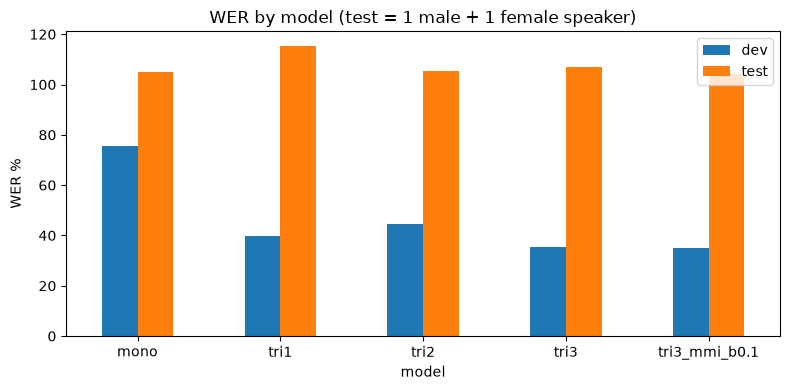

In [20]:
df = pd.DataFrame(RESULTS).drop_duplicates(["model","data"], keep="last")
order = ["mono","tri1","tri2","tri3","tri3_mmi_b0.1","tdnn"]
df["model"] = pd.Categorical(df["model"], [m for m in order if m in set(df.model)]
                             + sorted(set(df.model) - set(order)), ordered=True)
table = df.pivot_table(index="model", columns="data", values=["WER","SER"], observed=True)
table = table.reindex(columns=pd.MultiIndex.from_product([["WER","SER"],["dev","test"]]))
display(table.round(2))
table.to_csv(S5/"RESULTS.csv")

ax = table["WER"].plot(kind="bar", figsize=(8,4), rot=0,
                       title="WER by model (test = 1 male + 1 female speaker)")
ax.set_ylabel("WER %"); ax.figure.tight_layout()
ax.figure.savefig(NB_DIR/"results_wer.png", dpi=120)

## 15 - Notes & limitations

* **Expect high WER regardless.** With only **2 training speakers** and ~1300
  utts the acoustic models are data-starved. `dev` (matched, random hold-out)
  shows the model progression; `test` (two unseen speakers, one male one
  female, per the assignment spec) is much harder and is the honest
  speaker-independent number. GMM tree/Gaussian counts are shrunk
  (`GMM_SIZES`) so the triphone models don't simply overfit past monophone.
  The real fix is still more *training* speakers - the assignment wants ~10;
  rebuild `data/` and rerun from section 4 as more land.
* **Already tried and ruled out as quick fixes** (see `step3_asr/README.md`
  for the numbers): a syllable-as-phone unit set (helps dev, hurts test - a
  wash) and wider LM-weight sweeps (no material change). This really is a
  data-size story, not a tuning one.
* **Closed vocabulary + bigram from the prompts** -> WER/SER here are optimistic
  vs. an open-vocabulary setting. Fine for comparing models to each other.
* One held-out test voice had a couple of truncated clips (dropped via
  `DROP_UTTS` in `speaker_config.py`) - see that speaker's `NOTES.txt` under
  `../recordings/`.
* **No SGMM2** in this image - the "advanced" model is boosted-MMI on tri3.
  The chain-TDNN cell is off by default (`RUN_CHAIN=False`); enable it only with
  spare time / RAM.
* **`nj` is capped by speaker count** (train 2, dev 2, test 1) because Kaldi
  splits by speaker. Raising `NJ_TRAIN` above 2 makes `train_mono.sh` refuse.
* Re-run `python build_notebook.py` after editing `build_notebook.py` to
  regenerate this notebook.